In [11]:
print('hello')

hello


In [12]:
# downloading the libraries

import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import pandas as pd
pd.set_option('display.max_columns', 100)
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap # correlation matrix

# worldcloud
import random
from wordcloud import WordCloud

# display ERD
from IPython.display import Image



# I - Exploring the data 

objective is to get more familiar with the data and review pandas / visulization logic

## A - Fetching the data 

In [ ]:
# understanding where the files are located with terminal operations



In [ ]:
# adding the path to fetch the files
raw_path = '/workspace/data/olist_datasets/'



In [14]:
# creating pandas dataframes from .csv
df_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')        


## B - Exploring the orders dataframe

In [28]:
# printing columns, null count, and dtypes for the orders dataframe
df_orders.info()   # shows the first 5 rows by default

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [41]:
# printing the first 10 lines of the orders dataframe
df_orders.head(10)

# the last 10 lines of the dataframe
df_orders.tail(10)

# a sample of ten lines
df_orders.sample(10)

# getting all null values
df_orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**why are there null values for approved_at, delivered_carrier_date, delivered_customer_date?**

*-> answer:*

In [24]:
# fetching only particular columns of the df_orders dataframe
## fetch the order_approved_at columns in a data series format, then in a dataframe format, and print the first five lines

## fetch the order_id, order_status, approved_at, delivered_carrier_date, delivered_customer_date


In [29]:
df_orders[['order_approved_at']]


,order_approved_at
0,2017-10-02 11:07:15
1,2018-07-26 03:24:27
2,2018-08-08 08:55:23
3,2017-11-18 19:45:59
4,2018-02-13 22:20:29
...,...
99436,2017-03-09 09:54:05
99437,2018-02-06 13:10:37
99438,2017-08-27 15:04:16
99439,2018-01-08 21:36:21


In [23]:
df_orders[['order_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,delivered,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01
99437,63943bddc261676b46f01ca7ac2f7bd8,delivered,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56
99438,83c1379a015df1e13d02aae0204711ab,delivered,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17
99439,11c177c8e97725db2631073c19f07b62,delivered,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54


In [30]:
# fetching the approved_at null columns - create another dataframe df_filtered, which will be filtered on order_approved_at is null, and print first 10 rows

df_filtered = df_orders[df_orders['order_approved_at'].isnull()]
df_filtered.head(10)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
3056,ddaec6fff982b13e7e048b627a11d6da,68f4ad79cc0c2ad06e19088f5c00e9fa,canceled,2016-10-04 19:41:32,NaN,NaN,NaN,2016-11-16 00:00:00
3094,5290c34bd38a8a095b885f13958db1e1,92af427e290117f39d9ff908566072e0,canceled,2018-08-21 10:25:18,NaN,NaN,NaN,2018-09-06 00:00:00
3684,03310aa823a66056268a3bab36e827fb,25dbbf0c477fd4ae0880aaffbb12e8b3,canceled,2018-08-07 16:33:59,NaN,NaN,NaN,2018-09-04 00:00:00
4373,4c8b9947280829d0a8b7e81cc249b875,403c35c4d8813bf67b3d396b91ca1619,canceled,2018-08-09 14:54:47,NaN,NaN,NaN,2018-08-21 00:00:00
4939,b13ea375fe9c728832688264638f84cf,0dc5884bc5ffba283678229f27e07ff9,canceled,2018-08-22 18:52:29,NaN,NaN,NaN,2018-09-19 00:00:00


In [ ]:
# count the order_id with a null approved_at by order_status

# with groupby method

'your code here'

# with value_counts method

'your code here'


In [31]:
df_filtered.groupby('order_status')['order_id'].count()

order_status
canceled     141
created        5
delivered     14
Name: order_id, dtype: int64

In [32]:
df_filtered['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

**what do you think of the results? Why is there a null approved at to begin with?**

-> *answer*:

## C - Creating a simple visualization using Matplotlib or Seaborn

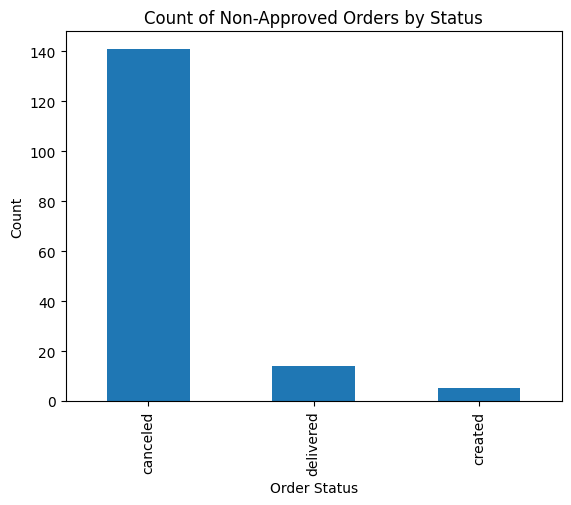

In [42]:
# Creating a simple plot with matplotlib: count of non-approved orders by status

df_filtered['order_status'].value_counts().plot(kind='bar')
plt.title('Count of Non-Approved Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.savefig('non_approved_orders.png')

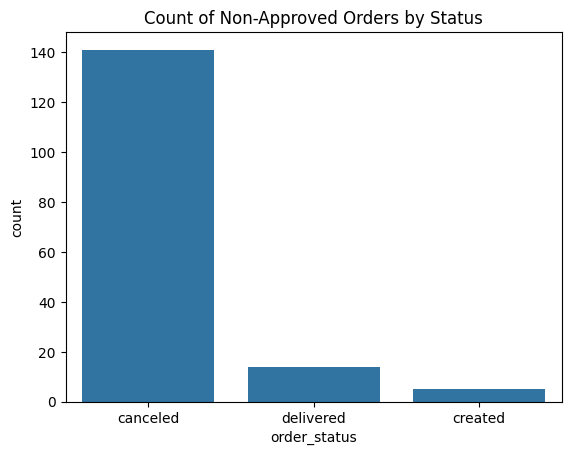

In [43]:
# Creating a simple plot with seaborn: count of non-approved orders by status

sns.countplot(data=df_filtered, x='order_status')
plt.title('Count of Non-Approved Orders by Status')
plt.show()

## D - Exploring all dataframes at once

In [44]:
# an interesting way to look at all dataframes at once, to quickly get what are the null columns

# Collections for each dataset
datasets = [df_customer, df_geolocation, df_orders, df_order_items, df_order_payments,
            df_order_reviews, df_products, df_sellers]
names = ['df_customer', 'df_geolocation', 'df_orders', 'df_order_items', 'df_order_payments',
         'df_order_reviews', 'df_products', 'df_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names
data_info['n_rows'] = [df.shape[0] for df in datasets]
data_info['n_cols'] = [df.shape[1] for df in datasets]
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

data_info.style.background_gradient()


,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,df_customer,99441,5,0,0,
1,df_geolocation,1000163,5,0,0,
2,df_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,df_order_items,112650,7,0,0,
4,df_order_payments,103886,5,0,0,
5,df_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,df_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,df_sellers,3095,4,0,0,


**What are the dataframes with the most null columns? What's your explanation?**

*->answer:*

## E - Joining 2 dataframes - how many orders were created in SP state?

In [45]:
# which dataframes do we need to join to answer the question? Explore the dataframes and look for a link between orders and state

df_orders_customers = pd.merge(df_orders, df_customer, on='customer_id', how='inner')



In [52]:
# Merge the 2 datasets in a new df_merged dataset, and print the first 5 rows

df_orders_customers.head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [53]:
# filter the dataframe to have only rows with state = SP, and print the first 5 lines

df_orders_customers[df_orders_customers['customer_state'] == 'SP'].head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP
11,34513ce0c4fab462a55830c0989c7edb,7711cf624183d843aafe81855097bc37,delivered,2017-07-13 19:58:11,2017-07-13 20:10:08,2017-07-14 18:43:29,2017-07-19 14:04:48,2017-08-08 00:00:00,782987b81c92239d922aa49d6bd4200b,4278,sao paulo,SP
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08 00:00:00,e2dfa3127fedbbca9707b36304996dab,4812,sao paulo,SP


In [54]:
# count the number of orders by state, using both groupby and value_counts

# with groupby method
df_orders_customers.groupby('customer_state')['order_id'].count()

# with value_counts method
df_orders_customers['customer_state'].value_counts()


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

# II - Exploratory analysis 

our objective is to a) give an overview of the business, b) understand what's driving the bad reviews

## A - Creating a uniform dataframe for our analysis

**Creating an ERD of the database**

- in an ERD diagram tool 
- create one item per table
- list all columns
- list their type
- find the primary and foreign keys
- link the tables together

--> upload directly the ERD in the notebook 

In [58]:
# Displaying the image with Ipython Image module
## the image is in the data/ERD folder        
filename = '../data/ERD/olist_erd.png'
Image(filename=filename)


FileNotFoundError: [Errno 2] No such file or directory: '../data/ERD/olist_erd.png'

In [ ]:
# Merging the dataframes using the ERD above

df = 'your code'


In [ ]:
# Cleaning the dataframe and creating additional columns that will be useful for further analysis

# Ensure timestamps are in datetime format
df['order_purchase_timestamp'] = 'your code'
df['order_delivered_customer_date'] = 'your code'
df['delivery_time'] = 'your code'

# Create useful features from order_purchase_timestamp
df['year'] = 'your code'                   # year as integer
df['month'] = 'your code'                  # month as integer
df['week'] = 'your code'                   # week in iso format (1, 2, 3 etc.)
df['day_of_week_int'] = 'your code'        # day of week as integer (1 = Monday, etc.)
df['hour'] = 'your code'                   # hour of day
df['year_month'] = 'your code'             # year and month, just like 2017-10

df.head()


## B - Looking at Reviews

### 1 - Let's look at the distribution of the review score

In [ ]:
# Create a distribution plot (dist plot) with seaborn on the review score

'your code'

**What do you make of those results?**

*->answer:*

### 2 - Let's look at the customer verbatims

In [ ]:
# Create a wordcloud on orders with negative reviews only

'your code'

**What are the first reasons you see behind a bad review? What could we do to improve this wordcloud?**

*-> answer:*

### 3 - Let's create a correlation matrix and identify other reasons behind bad reviews

In [ ]:
# let's isolate the columns we'll use for our correlation matrix

# print all the columns and their types using the method of your choice


In [ ]:
# bonus: can we create additional features?
# example: create a is_delivered column?

'your code'


In [ ]:
# Create the correlation matrix based on the columns you want

# Select relevant features for correlation analysis

colors = ['#001F3F', '#0074D9', '#7FDBFF', '#39CCCC', '#3D9970', '#2ECC40', '#01FF70']

correlation_features = df[['columns_you_want']]

# Calculate the correlation matrix
correlation = correlation_features.corr()

# use seaborn to print the correlation matrix
'your code'


**What are the correlations you see?**

*-> answer:*

## C - Looking at orders

### 1 - Orders by statuses

In [ ]:
# Create a visualization to count the orders by statuses

'your code here'


### 2 - Evolution of total orders over time

In [ ]:
# Create a visualization to see the evolution of orders over time

'your code here'


### 3 - Comparing 2017 and 2018 (bonus)

In [ ]:
# Create a visualization to compare 2017 and 2018 on the same graph (bar charts with a "hue" = 'year'

'your code here'


## D - Delivery times

### 1 - Delivery time by product category

In [ ]:
# Start by counting the orders by product category, and create an 'Other section' for product categories that have the lowest amount of orders

# Count the occurrences of each product category
'your code here'

# Only keep the product category that are above a certain threshold, put the others in a "Other' category
threshold = 3000  
'your code here'


In [ ]:
# Create a boxplot visualization that shows the delivery time by product category

'your code here'


### 2 - Delivery time by day of the week

In [ ]:
# Create a violin box plot visualization to see the delivery time by day of the week

'your code here'


### 3 - Average delivery time by month  (bonus)

In [ ]:
# Create barplot for the monthly average delivery time

'your code here'


## E - Bonus

### 1 - Order distribution by day of week and time of day 

In [ ]:
# Count plot showing order distribution by day of week

'your code here'


In [ ]:
# Count plot showing order distribution by time of day

'your code here'


### 2 - Payments

In [ ]:
# Create a donut (pie chart) that show transactions by payment types

'your code here'



In [ ]:
# Show the evolution of payment types over time

'your code here'


### 3 - Geolocation

In [ ]:
# Create a heatmap of all orders by location using an API to retrieve the latitude and longitude of every location, and display them on a map

'your code here'


### 4 - Profit computation

In [ ]:
# Show the monthly profit evolution for the best 4 product categories
# x axis: months
# y axis: gross profit (payment value - total order value)
# hue : top product categories

'your code here'
